In [14]:
import pandas as pd
import torch
import torch.nn as nn
import dgl
from dgl.nn import GATConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ==============================================================
# FUNCTIONS
# ==============================================================
def calculate_smape(y_true, y_pred):
    """Calcule SMAPE (0-200%, plus bas = meilleur)"""
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(numerator[mask] / denominator[mask]) * 100

def evaluate_metrics(y_true, y_pred, threshold=None, dataset_name="Dataset"):
    """Évaluer les métriques avec seuil optionnel"""
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    if threshold is not None:
        mask = y_true_flat >= threshold
        if mask.sum() < 10:
            print(f"⚠️ Pas assez de données >= {threshold:,}")
            return None
        y_true_flat = y_true_flat[mask]
        y_pred_flat = y_pred_flat[mask]
        n_total = len(y_true.flatten())
        pct = len(y_true_flat) / n_total * 100
        scope = f"(>= {threshold:,} USD, {pct:.1f}%)"
    else:
        scope = "(all flows)"
    
    mse = mean_squared_error(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    r2 = r2_score(y_true_flat, y_pred_flat)
    smape = calculate_smape(y_true_flat, y_pred_flat)
    
    print(f"{dataset_name:20s} {scope:35s} | n={len(y_true_flat):>10,} | R²={r2:.4f} | SMAPE={smape:.2f}%")
    
    return {'mse': mse, 'mae': mae, 'r2': r2, 'smape': smape, 'n': len(y_true_flat)}

def evaluate_dataset(model, df_eval, train_agg_features, country_code_map, scaler_features, scaler_target, batch_size, dataset_name):
    """Évaluer le modèle sur un dataset spécifique"""
    
    print(f"\n{'='*120}")
    print(f"EVALUATION: {dataset_name}")
    print(f"{'='*120}")
    
    df_eval = df_eval.copy()
    
    for col in ['gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist']:
        df_eval[col].fillna(df_eval[col].mean() if df_eval[col].mean() == df_eval[col].mean() else 0, inplace=True)
    
    df_eval['nodeID'] = df_eval['reporterCode'].map(country_code_map)
    df_eval['partnerNodeID'] = df_eval['partnerCode'].map(country_code_map)
    
    df_eval_filtered = df_eval.dropna(subset=['nodeID', 'partnerNodeID']).copy()
    df_eval_filtered['nodeID'] = df_eval_filtered['nodeID'].astype(int)
    df_eval_filtered['partnerNodeID'] = df_eval_filtered['partnerNodeID'].astype(int)
    
    print(f"Original size: {len(df_eval):,}, After filtering unknown countries: {len(df_eval_filtered):,}")
    
    if len(df_eval_filtered) == 0:
        print(f"⚠️ Pas de données pour {dataset_name}")
        return None, None, None
    
    agg_features_eval = df_eval_filtered.groupby(['refYear', 'reporterCode', 'cmdCode']).agg({
        'primaryValue': 'mean',
        'dist': 'first',
        'gdpcap_d': 'sum',
        'gdpcap_o': 'sum',
        'pop_d': 'sum',
        'pop_o': 'sum'
    }).reset_index()
    
    eval_country_map = {code: i for i, code in enumerate(agg_features_eval['reporterCode'])}
    
    features_eval = agg_features_eval[[ 'refYear', 'cmdCode', 'dist', 'gdpcap_d', 'gdpcap_o', 'pop_o', 'pop_d']]
    normalized_features_eval = scaler_features.transform(features_eval)
    normalized_target_eval = scaler_target.transform(agg_features_eval[['primaryValue']])
    
    df_eval_filtered['evalNodeID'] = df_eval_filtered['reporterCode'].map(eval_country_map)
    df_eval_filtered['evalPartnerID'] = df_eval_filtered['partnerCode'].map(eval_country_map)
    df_eval_filtered = df_eval_filtered.dropna(subset=['evalNodeID', 'evalPartnerID'])
    df_eval_filtered['evalNodeID'] = df_eval_filtered['evalNodeID'].astype(int)
    df_eval_filtered['evalPartnerID'] = df_eval_filtered['evalPartnerID'].astype(int)
    
    eval_g = dgl.graph((df_eval_filtered['evalNodeID'].to_numpy(), 
                        df_eval_filtered['evalPartnerID'].to_numpy()))
    
    eval_feat_tensor = torch.tensor(normalized_features_eval, dtype=torch.float32)
    eval_g.ndata['feat'] = eval_feat_tensor
    eval_g = dgl.add_self_loop(eval_g)
    
    model.eval()
    predictions = []
    num_nodes_eval = eval_g.num_nodes()
    
    for i in range(0, num_nodes_eval, batch_size):
        batch_nodes = list(range(i, min(i + batch_size, num_nodes_eval)))
        batch_graph = eval_g.subgraph(batch_nodes)
        
        with torch.no_grad():
            logits = model(batch_graph, batch_graph.ndata['feat'])
            predictions.append(logits.unsqueeze(1))
    
    predictions = torch.cat(predictions, dim=0)
    predictions_np = predictions.view(predictions.size(0), -1).numpy()
    
    y_pred = scaler_target.inverse_transform(predictions_np)
    y_true = scaler_target.inverse_transform(normalized_target_eval)
    
    results = {}
    results['all'] = evaluate_metrics(y_true, y_pred, threshold=None, dataset_name=dataset_name)
    results['gte_1M'] = evaluate_metrics(y_true, y_pred, threshold=1_000_000, dataset_name=dataset_name)
    results['gte_10M'] = evaluate_metrics(y_true, y_pred, threshold=10_000_000, dataset_name=dataset_name)
    results['gte_100M'] = evaluate_metrics(y_true, y_pred, threshold=100_000_000, dataset_name=dataset_name)
    
    return results, y_true, y_pred

# ==============================================================
# DATA LOADING
# ==============================================================
print("="*60)
print("LOADING DATA")
print("="*60)

##source
df = pd.read_parquet("chips.parquet")

# getting numeric values
for c in ['gdp_o','gdp_d','gdpcap_o','gdpcap_d','dist','pop_o','pop_d','primaryValue','refYear','cmdCode','reporterCode','partnerCode']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['gdpcap_o'] = df['gdpcap_o'] / 1_000_000
df['gdp_o']    = df['gdp_o'] / 1_000_000
df['gdp_d']    = df['gdp_d'] / 1_000_000
df['gdpcap_d'] = df['gdpcap_d'] / 1_000_000
df['dist']     = df['dist'] / 1_000

df = df[df['cmdCode'] != 'TOTAL']
df = df[df['cmdCode'].astype(str).str.isdigit()]
df['cmdCode'] = df['cmdCode'].astype(int)
#df = df[df['cmdCode'] > 99999]

data_all = df[['refYear', 'reporterCode', 'partnerCode', 'cmdCode', 'gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist', 'primaryValue']]
data_all = data_all.drop_duplicates(['refYear', 'reporterCode', 'partnerCode', 'cmdCode'], keep='first').reset_index(drop=True)

# ==============================================================
# SPLIT PAR ANNÉE: Train 2017-2022, Test 2023
# ==============================================================
data_train_full = data_all[data_all['refYear'].isin([2017, 2018, 2019, 2020, 2021, 2022])].copy()
data_2023 = data_all[data_all['refYear'] == 2023].copy()

print(f"Train data (2017-2022): {data_train_full.shape[0]:,}")
print(f"Test 2023: {data_2023.shape[0]:,}")
print(f"Years in train: {sorted(data_train_full['refYear'].unique())}")

# Handle missing values
for col in ['gdpcap_o', 'pop_o']:
    data_train_full[col] = data_train_full.groupby(['refYear', 'reporterCode'])[col].transform(lambda x: x.fillna(x.mean()))
for col in ['gdpcap_d', 'pop_d']:
    data_train_full[col] = data_train_full.groupby(['refYear', 'partnerCode'])[col].transform(lambda x: x.fillna(x.mean()))
data_train_full['dist'] = data_train_full.groupby(['refYear', 'reporterCode', 'partnerCode'])['dist'].transform(lambda x: x.fillna(x.mean()))

for col in ['gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist']:
    data_train_full[col].fillna(data_train_full[col].mean(), inplace=True)

# ==============================================================
# TRAIN/VAL SPLIT (80/20)
# ==============================================================
grouped_data = data_train_full.groupby('reporterCode')
train_data = pd.DataFrame()
val_data = pd.DataFrame()

for name, group in grouped_data:
    if len(group) < 5:                 # too few rows to split — put them all in train
        train_data = pd.concat([train_data, group])
        continue
    train_group, val_group = train_test_split(group, test_size=0.2, random_state=42)
    train_data = pd.concat([train_data, train_group])
    val_data = pd.concat([val_data, val_group])

print(f"\nTrain size: {train_data.shape[0]:,}")
print(f"Validation size: {val_data.shape[0]:,}")

# ==============================================================
# FEATURE ENGINEERING
# ==============================================================
agg_features = train_data.groupby(['refYear', 'reporterCode', 'cmdCode']).agg({
    'primaryValue': 'mean',
    'dist': 'first',
    'gdpcap_d': 'sum',
    'gdpcap_o': 'sum',
    'pop_d': 'sum',
    'pop_o': 'sum'
}).reset_index()

country_code_map = {code: i for i, code in enumerate(agg_features['reporterCode'])}

train_data = train_data.copy()
train_data.loc[:, 'nodeID'] = train_data['reporterCode'].map(country_code_map)

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

features_to_normalize = agg_features[['refYear', 'cmdCode', 'dist', 'gdpcap_d', 'gdpcap_o', 'pop_o', 'pop_d']]
normalized_features = scaler_features.fit_transform(features_to_normalize)
normalized_target = scaler_target.fit_transform(agg_features[['primaryValue']])

# ==============================================================
# CREATE GRAPH
# ==============================================================
g = dgl.graph((train_data['nodeID'].to_numpy(), train_data['partnerCode'].map(country_code_map).to_numpy()))
feat_tensor = torch.tensor(normalized_features, dtype=torch.float32)
g.ndata['feat'] = feat_tensor
g = dgl.add_self_loop(g)

print(f"\nGraph: {g.num_nodes()} nodes, {g.num_edges()} edges")

# ==============================================================
# MODEL
# ==============================================================
class GATRegressionModel(nn.Module):
    def __init__(self, in_feats, hidden_feats, num_heads):
        super(GATRegressionModel, self).__init__()
        self.conv1 = GATConv(in_feats, hidden_feats, num_heads)
        self.conv2 = GATConv(hidden_feats * num_heads, 1, num_heads)
    
    def forward(self, g, features):
        x = torch.relu(self.conv1(g, features).flatten(1))
        x = self.conv2(g, x).mean(1)
        return x

in_feats = 7
hidden_feats = 32
num_heads = 4

model = GATRegressionModel(in_feats, hidden_feats, num_heads)

# ==============================================================
# TRAINING
# ==============================================================
batch_size = 10000
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
num_nodes = g.num_nodes()
num_batches = num_nodes // batch_size + (num_nodes % batch_size > 0)
num_epochs = 100

print("\n" + "="*60)
print("TRAINING (2017-2022)")
print("="*60)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    
    for i in range(num_batches):
        batch_nodes = list(range(i * batch_size, min((i + 1) * batch_size, num_nodes)))
        batch_graph = g.subgraph(batch_nodes)
        
        logits = model(batch_graph, batch_graph.ndata['feat'])
        target = torch.tensor(normalized_target[batch_nodes, 0], dtype=torch.float32).view(-1, 1)
        
        loss = criterion(logits.view(-1, 1), target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    losses.append(epoch_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{num_epochs} | Loss: {epoch_loss:.6f}')

print("\n✓ Training complete!")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (2017-2022)')
plt.grid(True, alpha=0.3)
plt.savefig('training_loss_2017_2022.png', dpi=300)
plt.show()

# ==============================================================
# EVALUATION: VALIDATION (2017-2022, 20%)
# ==============================================================
results_val, y_true_val, y_pred_val = evaluate_dataset(
    model, val_data, agg_features, country_code_map,
    scaler_features, scaler_target, batch_size, "Validation (2017-2022)"
)

# ==============================================================
# EVALUATION: TEST 2023
# ==============================================================
results_2023, y_true_2023, y_pred_2023 = evaluate_dataset(
    model, data_2023, agg_features, country_code_map,
    scaler_features, scaler_target, batch_size, "Test 2023"
)

# ==============================================================
# DIAGNOSTIC PAR TRANCHE
# ==============================================================
print("\n" + "="*120)
print("DIAGNOSTIC PAR TRANCHE DE VALEURS (Validation 2017-2022)")
print("="*120)

if y_true_val is not None:
    y_true_flat = y_true_val.flatten()
    y_pred_flat = y_pred_val.flatten()
    
    tranches = [
        ('< 100K USD', y_true_flat < 100_000),
        ('100K - 1M USD', (y_true_flat >= 100_000) & (y_true_flat < 1_000_000)),
        ('1M - 10M USD', (y_true_flat >= 1_000_000) & (y_true_flat < 10_000_000)),
        ('10M - 100M USD', (y_true_flat >= 10_000_000) & (y_true_flat < 100_000_000)),
        ('> 100M USD', y_true_flat >= 100_000_000)
    ]
    
    for nom, mask in tranches:
        if mask.sum() > 1:
            r2_t = r2_score(y_true_flat[mask], y_pred_flat[mask])
            smape_t = calculate_smape(y_true_flat[mask], y_pred_flat[mask])
            print(f"{nom:25s} | n={mask.sum():>10,} | R²={r2_t:>8.4f} | SMAPE={smape_t:>6.2f}%")

# ==============================================================
# SUMMARY TABLE
# ==============================================================
print("\n" + "="*100)
print("SUMMARY TABLE")
print("="*100)

all_results = [
    ("Validation (2017-2022)", results_val),
    ("Test 2023", results_2023)
]

# Table >= 100M USD
print("\n--- Flux >= 100M USD ---")
print(f"{'Dataset':<25} | {'n':>8} | {'MSE':>15} | {'MAE':>12} | {'R²':>8} | {'SMAPE':>10}")
print("-"*90)

for name, results in all_results:
    if results and results.get('gte_100M'):
        r = results['gte_100M']
        print(f"{name:<25} | {r['n']:>8,} | {r['mse']:>15,.2f} | {r['mae']:>12,.2f} | {r['r2']:>8.4f} | {r['smape']:>9.2f}%")

# ==============================================================
# LATEX TABLE
# ==============================================================
print("\n" + "="*100)
print("LATEX TABLE (>= 100M USD)")
print("="*100)

print(r"""
\begin{table}[h]
\centering
\caption{GAT Model Performance for Trade Flow Prediction (trained on 2017-2022, flows $\geq$ 100M USD)}
\label{tab:results_2017_2022}
\begin{tabular}{l|r|r|r|c|c}
Dataset & n & MSE & MAE & R² & SMAPE \\
\hline""")

for name, results in all_results:
    if results and results.get('gte_100M'):
        r = results['gte_100M']
        print(f"{name} & {r['n']:,} & {r['mse']:,.2f} & {r['mae']:,.2f} & {r['r2']:.2f} & {r['smape']:.2f}\\% \\\\")

print(r"""\end{tabular}
\end{table}
""")

# ==============================================================
# SAVE MODEL
# ==============================================================
torch.save(model.state_dict(), 'model_gat_2017_2022_chips.pth')
print("\n✓ Model saved: model_gat_2017_2022.pth")

LOADING DATA
Train data (2017-2022): 230,095
Test 2023: 34,721
Years in train: [2017, 2018, 2019, 2020, 2021, 2022]


KeyboardInterrupt: 

LOADING DATA
Train data (2017-2022): 433,673
Test 2023: 66,017
Years in train: [2017, 2018, 2019, 2020, 2021, 2022]

Train size: 346,881
Validation size: 86,792

Graph: 11619 nodes, 358500 edges

TRAINING (2017-2022)
Epoch  10/100 | Loss: 0.001946
Epoch  20/100 | Loss: 0.000327
Epoch  30/100 | Loss: 0.000104
Epoch  40/100 | Loss: 0.000064
Epoch  50/100 | Loss: 0.000050
Epoch  60/100 | Loss: 0.000042
Epoch  70/100 | Loss: 0.000037
Epoch  80/100 | Loss: 0.000034
Epoch  90/100 | Loss: 0.000031
Epoch 100/100 | Loss: 0.000029

✓ Training complete!


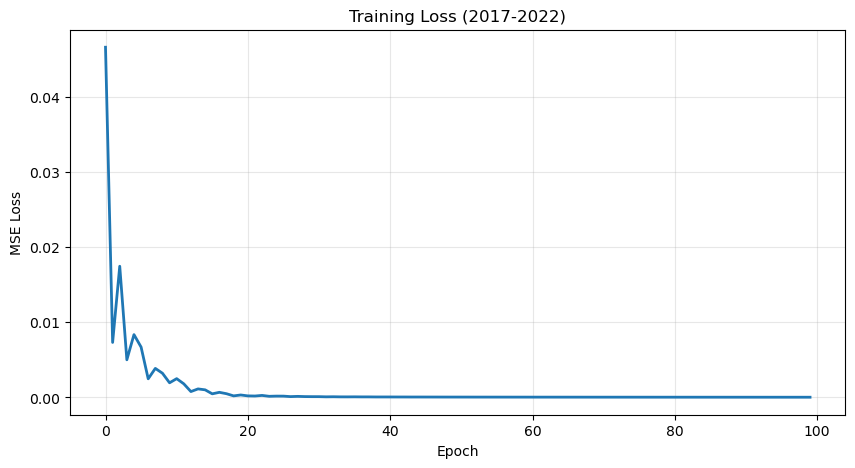


EVALUATION: Validation (2017-2022)
Original size: 86,792, After filtering unknown countries: 79,447
Validation (2017-2022) (all flows)                         | n=     9,157 | R²=0.9894 | SMAPE=157.72%
Validation (2017-2022) (>= 1,000,000 USD, 25.9%)           | n=     2,368 | R²=0.9896 | SMAPE=76.06%
Validation (2017-2022) (>= 10,000,000 USD, 9.5%)           | n=       873 | R²=0.9888 | SMAPE=30.78%
Validation (2017-2022) (>= 100,000,000 USD, 2.5%)          | n=       230 | R²=0.9854 | SMAPE=16.87%

EVALUATION: Test 2023
Original size: 66,017, After filtering unknown countries: 60,210
Test 2023            (all flows)                         | n=     1,611 | R²=0.9789 | SMAPE=161.92%
Test 2023            (>= 1,000,000 USD, 23.7%)           | n=       382 | R²=0.9889 | SMAPE=79.30%
Test 2023            (>= 10,000,000 USD, 8.6%)           | n=       138 | R²=0.9912 | SMAPE=23.60%
Test 2023            (>= 100,000,000 USD, 2.1%)          | n=        34 | R²=0.9886 | SMAPE=8.83%

DIAGNOSTI

In [5]:
import pandas as pd
import torch
import torch.nn as nn
import dgl
from dgl.nn import GATConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ==============================================================
# FUNCTIONS
# ==============================================================
def calculate_smape(y_true, y_pred):
    """Calcule SMAPE (0-200%, plus bas = meilleur)"""
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(numerator[mask] / denominator[mask]) * 100

def evaluate_metrics(y_true, y_pred, threshold=None, dataset_name="Dataset"):
    """Évaluer les métriques avec seuil optionnel"""
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    if threshold is not None:
        mask = y_true_flat >= threshold
        if mask.sum() < 10:
            print(f"⚠️ Pas assez de données >= {threshold:,}")
            return None
        y_true_flat = y_true_flat[mask]
        y_pred_flat = y_pred_flat[mask]
        n_total = len(y_true.flatten())
        pct = len(y_true_flat) / n_total * 100
        scope = f"(>= {threshold:,} USD, {pct:.1f}%)"
    else:
        scope = "(all flows)"

    mse = mean_squared_error(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    r2 = r2_score(y_true_flat, y_pred_flat)
    smape = calculate_smape(y_true_flat, y_pred_flat)

    print(f"{dataset_name:20s} {scope:35s} | n={len(y_true_flat):>10,} | R²={r2:.4f} | SMAPE={smape:.2f}%")

    return {'mse': mse, 'mae': mae, 'r2': r2, 'smape': smape, 'n': len(y_true_flat)}

def evaluate_dataset(model, df_eval, train_agg_features, country_code_map, scaler_features, scaler_target, batch_size, dataset_name):
    """Évaluer le modèle sur un dataset spécifique"""

    print(f"\n{'='*120}")
    print(f"EVALUATION: {dataset_name}")
    print(f"{'='*120}")

    df_eval = df_eval.copy()

    for col in ['gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist']:
        df_eval[col].fillna(df_eval[col].mean() if df_eval[col].mean() == df_eval[col].mean() else 0, inplace=True)

    df_eval['nodeID'] = df_eval['reporterCode'].map(country_code_map)
    df_eval['partnerNodeID'] = df_eval['partnerCode'].map(country_code_map)

    df_eval_filtered = df_eval.dropna(subset=['nodeID', 'partnerNodeID']).copy()
    df_eval_filtered['nodeID'] = df_eval_filtered['nodeID'].astype(int)
    df_eval_filtered['partnerNodeID'] = df_eval_filtered['partnerNodeID'].astype(int)

    print(f"Original size: {len(df_eval):,}, After filtering unknown countries: {len(df_eval_filtered):,}")

    if len(df_eval_filtered) == 0:
        print(f"⚠️ Pas de données pour {dataset_name}")
        return None, None, None

    agg_features_eval = df_eval_filtered.groupby(['refYear', 'reporterCode', 'cmdCode']).agg({
        'primaryValue': 'mean',
        'dist': 'first',
        'gdpcap_d': 'sum',
        'gdpcap_o': 'sum',
        'pop_d': 'sum',
        'pop_o': 'sum'
    }).reset_index()

    eval_country_map = {code: i for i, code in enumerate(agg_features_eval['reporterCode'])}

    features_eval = agg_features_eval[['primaryValue', 'refYear', 'cmdCode', 'dist', 'gdpcap_d', 'gdpcap_o', 'pop_o', 'pop_d']]
    normalized_features_eval = scaler_features.transform(features_eval)
    normalized_target_eval = scaler_target.transform(agg_features_eval[['primaryValue']])

    df_eval_filtered['evalNodeID'] = df_eval_filtered['reporterCode'].map(eval_country_map)
    df_eval_filtered['evalPartnerID'] = df_eval_filtered['partnerCode'].map(eval_country_map)
    df_eval_filtered = df_eval_filtered.dropna(subset=['evalNodeID', 'evalPartnerID'])
    df_eval_filtered['evalNodeID'] = df_eval_filtered['evalNodeID'].astype(int)
    df_eval_filtered['evalPartnerID'] = df_eval_filtered['evalPartnerID'].astype(int)

    eval_g = dgl.graph((df_eval_filtered['evalNodeID'].to_numpy(),
                        df_eval_filtered['evalPartnerID'].to_numpy()))

    eval_feat_tensor = torch.tensor(normalized_features_eval, dtype=torch.float32)
    eval_g.ndata['feat'] = eval_feat_tensor
    eval_g = dgl.add_self_loop(eval_g)

    model.eval()
    predictions = []
    num_nodes_eval = eval_g.num_nodes()

    for i in range(0, num_nodes_eval, batch_size):
        batch_nodes = list(range(i, min(i + batch_size, num_nodes_eval)))
        batch_graph = eval_g.subgraph(batch_nodes)

        with torch.no_grad():
            logits = model(batch_graph, batch_graph.ndata['feat'])
            predictions.append(logits.unsqueeze(1))

    predictions = torch.cat(predictions, dim=0)
    predictions_np = predictions.view(predictions.size(0), -1).numpy()

    y_pred = scaler_target.inverse_transform(predictions_np)
    y_true = scaler_target.inverse_transform(normalized_target_eval)

    results = {}
    results['all'] = evaluate_metrics(y_true, y_pred, threshold=None, dataset_name=dataset_name)
    results['gte_1M'] = evaluate_metrics(y_true, y_pred, threshold=1_000_000, dataset_name=dataset_name)
    results['gte_10M'] = evaluate_metrics(y_true, y_pred, threshold=10_000_000, dataset_name=dataset_name)
    results['gte_100M'] = evaluate_metrics(y_true, y_pred, threshold=100_000_000, dataset_name=dataset_name)

    return results, y_true, y_pred

# ==============================================================
# DATA LOADING
# ==============================================================
print("="*60)
print("LOADING DATA")
print("="*60)

##source
df = pd.read_parquet("electronics.parquet")

# getting numeric values
for c in ['gdp_o','gdp_d','gdpcap_o','gdpcap_d','dist','pop_o','pop_d','primaryValue','refYear','cmdCode','reporterCode','partnerCode']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['gdpcap_o'] = df['gdpcap_o'] / 1_000_000
df['gdp_o']    = df['gdp_o'] / 1_000_000
df['gdp_d']    = df['gdp_d'] / 1_000_000
df['gdpcap_d'] = df['gdpcap_d'] / 1_000_000
df['dist']     = df['dist'] / 1_000

df = df[df['cmdCode'] != 'TOTAL']
df = df[df['cmdCode'].astype(str).str.isdigit()]
df['cmdCode'] = df['cmdCode'].astype(int)
#df = df[df['cmdCode'] > 99999]

data_all = df[['refYear', 'reporterCode', 'partnerCode', 'cmdCode', 'gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist', 'primaryValue']]
data_all = data_all.drop_duplicates(['refYear', 'reporterCode', 'partnerCode', 'cmdCode'], keep='first').reset_index(drop=True)

# ==============================================================
# SPLIT PAR ANNÉE: Train 2017-2022, Test 2023
# ==============================================================
data_train_full = data_all[data_all['refYear'].isin([2017, 2018, 2019, 2020, 2021, 2022])].copy()
data_2023 = data_all[data_all['refYear'] == 2023].copy()

print(f"Train data (2017-2022): {data_train_full.shape[0]:,}")
print(f"Test 2023: {data_2023.shape[0]:,}")
print(f"Years in train: {sorted(data_train_full['refYear'].unique())}")

# Handle missing values
for col in ['gdpcap_o', 'pop_o']:
    data_train_full[col] = data_train_full.groupby(['refYear', 'reporterCode'])[col].transform(lambda x: x.fillna(x.mean()))
for col in ['gdpcap_d', 'pop_d']:
    data_train_full[col] = data_train_full.groupby(['refYear', 'partnerCode'])[col].transform(lambda x: x.fillna(x.mean()))
data_train_full['dist'] = data_train_full.groupby(['refYear', 'reporterCode', 'partnerCode'])['dist'].transform(lambda x: x.fillna(x.mean()))

for col in ['gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist']:
    data_train_full[col].fillna(data_train_full[col].mean(), inplace=True)

# ==============================================================
# TRAIN/VAL SPLIT (80/20)
# ==============================================================
grouped_data = data_train_full.groupby('reporterCode')
train_data = pd.DataFrame()
val_data = pd.DataFrame()

for name, group in grouped_data:
    if len(group) < 5:                 # too few rows to split — put them all in train
        train_data = pd.concat([train_data, group])
        continue
    train_group, val_group = train_test_split(group, test_size=0.2, random_state=42)
    train_data = pd.concat([train_data, train_group])
    val_data = pd.concat([val_data, val_group])

print(f"\nTrain size: {train_data.shape[0]:,}")
print(f"Validation size: {val_data.shape[0]:,}")

# ==============================================================
# FEATURE ENGINEERING
# ==============================================================
agg_features = train_data.groupby(['refYear', 'reporterCode', 'cmdCode']).agg({
    'primaryValue': 'mean',
    'dist': 'first',
    'gdpcap_d': 'sum',
    'gdpcap_o': 'sum',
    'pop_d': 'sum',
    'pop_o': 'sum'
}).reset_index()

country_code_map = {code: i for i, code in enumerate(agg_features['reporterCode'])}

train_data = train_data.copy()
train_data.loc[:, 'nodeID'] = train_data['reporterCode'].map(country_code_map)

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

features_to_normalize = agg_features[['primaryValue', 'refYear', 'cmdCode', 'dist', 'gdpcap_d', 'gdpcap_o', 'pop_o', 'pop_d']]
normalized_features = scaler_features.fit_transform(features_to_normalize)
normalized_target = scaler_target.fit_transform(agg_features[['primaryValue']])

# ==============================================================
# CREATE GRAPH
# ==============================================================
g = dgl.graph((train_data['nodeID'].to_numpy(), train_data['partnerCode'].map(country_code_map).to_numpy()))
feat_tensor = torch.tensor(normalized_features, dtype=torch.float32)
g.ndata['feat'] = feat_tensor
g = dgl.add_self_loop(g)

print(f"\nGraph: {g.num_nodes()} nodes, {g.num_edges()} edges")

# ==============================================================
# MODEL
# ==============================================================
class GATRegressionModel(nn.Module):
    def __init__(self, in_feats, hidden_feats, num_heads):
        super(GATRegressionModel, self).__init__()
        self.conv1 = GATConv(in_feats, hidden_feats, num_heads)
        self.conv2 = GATConv(hidden_feats * num_heads, 1, num_heads)

    def forward(self, g, features):
        x = torch.relu(self.conv1(g, features).flatten(1))
        x = self.conv2(g, x).mean(1)
        return x

in_feats = 8
hidden_feats = 32
num_heads = 4

model = GATRegressionModel(in_feats, hidden_feats, num_heads)

# ==============================================================
# TRAINING
# ==============================================================
batch_size = 10000
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
num_nodes = g.num_nodes()
num_batches = num_nodes // batch_size + (num_nodes % batch_size > 0)
num_epochs = 100

print("\n" + "="*60)
print("TRAINING (2017-2022)")
print("="*60)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for i in range(num_batches):
        batch_nodes = list(range(i * batch_size, min((i + 1) * batch_size, num_nodes)))
        batch_graph = g.subgraph(batch_nodes)

        logits = model(batch_graph, batch_graph.ndata['feat'])
        target = torch.tensor(normalized_target[batch_nodes, 0], dtype=torch.float32).view(-1, 1)

        loss = criterion(logits.view(-1, 1), target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{num_epochs} | Loss: {epoch_loss:.6f}')

print("\n✓ Training complete!")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (2017-2022)')
plt.grid(True, alpha=0.3)
plt.savefig('training_loss_2017_2022.png', dpi=300)
plt.show()

# ==============================================================
# EVALUATION: VALIDATION (2017-2022, 20%)
# ==============================================================
results_val, y_true_val, y_pred_val = evaluate_dataset(
    model, val_data, agg_features, country_code_map,
    scaler_features, scaler_target, batch_size, "Validation (2017-2022)"
)

# ==============================================================
# EVALUATION: TEST 2023
# ==============================================================
results_2023, y_true_2023, y_pred_2023 = evaluate_dataset(
    model, data_2023, agg_features, country_code_map,
    scaler_features, scaler_target, batch_size, "Test 2023"
)

# ==============================================================
# DIAGNOSTIC PAR TRANCHE
# ==============================================================
print("\n" + "="*120)
print("DIAGNOSTIC PAR TRANCHE DE VALEURS (Validation 2017-2022)")
print("="*120)

if y_true_val is not None:
    y_true_flat = y_true_val.flatten()
    y_pred_flat = y_pred_val.flatten()

    tranches = [
        ('< 100K USD', y_true_flat < 100_000),
        ('100K - 1M USD', (y_true_flat >= 100_000) & (y_true_flat < 1_000_000)),
        ('1M - 10M USD', (y_true_flat >= 1_000_000) & (y_true_flat < 10_000_000)),
        ('10M - 100M USD', (y_true_flat >= 10_000_000) & (y_true_flat < 100_000_000)),
        ('> 100M USD', y_true_flat >= 100_000_000)
    ]

    for nom, mask in tranches:
        if mask.sum() > 1:
            r2_t = r2_score(y_true_flat[mask], y_pred_flat[mask])
            smape_t = calculate_smape(y_true_flat[mask], y_pred_flat[mask])
            print(f"{nom:25s} | n={mask.sum():>10,} | R²={r2_t:>8.4f} | SMAPE={smape_t:>6.2f}%")

# ==============================================================
# SUMMARY TABLE
# ==============================================================
print("\n" + "="*100)
print("SUMMARY TABLE")
print("="*100)

all_results = [
    ("Validation (2017-2022)", results_val),
    ("Test 2023", results_2023)
]

# Table >= 100M USD
print("\n--- Flux >= 100M USD ---")
print(f"{'Dataset':<25} | {'n':>8} | {'MSE':>15} | {'MAE':>12} | {'R²':>8} | {'SMAPE':>10}")
print("-"*90)

for name, results in all_results:
    if results and results.get('gte_100M'):
        r = results['gte_100M']
        print(f"{name:<25} | {r['n']:>8,} | {r['mse']:>15,.2f} | {r['mae']:>12,.2f} | {r['r2']:>8.4f} | {r['smape']:>9.2f}%")

# ==============================================================
# LATEX TABLE
# ==============================================================
print("\n" + "="*100)
print("LATEX TABLE (>= 100M USD)")
print("="*100)

print(r"""
\begin{table}[h]
\centering
\caption{GAT Model Performance for Trade Flow Prediction (trained on 2017-2022, flows $\geq$ 100M USD)}
\label{tab:results_2017_2022}
\begin{tabular}{l|r|r|r|c|c}
Dataset & n & MSE & MAE & R² & SMAPE \\
\hline""")

for name, results in all_results:
    if results and results.get('gte_100M'):
        r = results['gte_100M']
        print(f"{name} & {r['n']:,} & {r['mse']:,.2f} & {r['mae']:,.2f} & {r['r2']:.2f} & {r['smape']:.2f}\\% \\\\")

print(r"""\end{tabular}
\end{table}
""")

# ==============================================================
# SAVE MODEL
# ==============================================================
torch.save(model.state_dict(), 'model_gat_2017_2022_electro.pth')
print("\n✓ Model saved: model_gat_2017_2022.pth")

---
+ GDELT data added

In [2]:
import pandas as pd
import torch
import torch.nn as nn
import dgl
from dgl.nn import GATConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:

# ===== EXPERIMENT CONFIG — change these to run each condition =====
USE_GDELT = True                       # False = baseline (no GDELT)
SCORING   = "keepall"                  # "keepall" | "topk"
GDELT_FILE = {"keepall": "gdelt_features_by_country_year.parquet",
              "topk":    "gdelt_features_topk.parquet"}[SCORING]

GDELT_COLS = ["events_total","score_mean","score_max","score_vol",
              "goldstein_wmean","tone_mean","active_months"]
BASE_COLS  = ['refYear','cmdCode','dist','gdpcap_d','gdpcap_o','pop_o','pop_d']
FEAT_COLS  = BASE_COLS + (GDELT_COLS if USE_GDELT else [])

if USE_GDELT:
    cy = pd.read_parquet(GDELT_FILE)

def add_gdelt(agg):
    """Concat GDELT country-year features onto agg (string-key merge = dtype-safe)."""
    out = agg.copy()
    out["_r"] = out["reporterCode"].astype("Int64").astype(str)
    out["_y"] = out["refYear"].astype("Int64").astype(str)
    cyk = cy.copy()
    cyk["_r"] = cyk["reporterCode"].astype("Int64").astype(str)
    cyk["_y"] = cyk["year"].astype("Int64").astype(str)
    out = out.merge(cyk[["_r","_y"]+GDELT_COLS], on=["_r","_y"], how="left")
    out[GDELT_COLS] = out[GDELT_COLS].fillna(0)
    return out.drop(columns=["_r","_y"])

def log_result(model, fusion, scoring, gdelt, risk_level, tranche, r2, mae, smape, n, notes=""):
    import os, csv
    from datetime import datetime
    RESULTS_FILE = "results.csv"
    row = {"timestamp": datetime.now().isoformat(timespec="seconds"),
           "model": model, "fusion": fusion, "scoring": scoring, "gdelt": gdelt,
           "risk_level": risk_level, "tranche": tranche,
           "r2": round(float(r2),4), "mae": round(float(mae),2),
           "smape": round(float(smape),2), "n": int(n), "notes": notes}
    new = not os.path.exists(RESULTS_FILE)
    with open(RESULTS_FILE, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if new: w.writeheader()
        w.writerow(row)
    return row

RUN = dict(model="GAT",
           fusion=("concat" if USE_GDELT else "none"),
           scoring=(SCORING if USE_GDELT else "none"),
           gdelt=USE_GDELT, risk_level="node")

### topk GAT

In [16]:

# ===== EXPERIMENT CONFIG — change these to run each condition =====
USE_GDELT = True                       # False = baseline (no GDELT)
SCORING   = "topk"                  # "keepall" | "topk"
GDELT_FILE = {"keepall": "gdelt_features_by_country_year.parquet",
              "topk":    "gdelt_features_topk.parquet"}[SCORING]

GDELT_COLS = ["events_total","score_mean","score_max","score_vol",
              "goldstein_wmean","tone_mean","active_months"]
BASE_COLS  = ['refYear','cmdCode','dist','gdpcap_d','gdpcap_o','pop_o','pop_d']
FEAT_COLS  = BASE_COLS + (GDELT_COLS if USE_GDELT else [])

if USE_GDELT:
    cy = pd.read_parquet(GDELT_FILE)

def add_gdelt(agg):
    """Concat GDELT country-year features onto agg (string-key merge = dtype-safe)."""
    out = agg.copy()
    out["_r"] = out["reporterCode"].astype("Int64").astype(str)
    out["_y"] = out["refYear"].astype("Int64").astype(str)
    cyk = cy.copy()
    cyk["_r"] = cyk["reporterCode"].astype("Int64").astype(str)
    cyk["_y"] = cyk["year"].astype("Int64").astype(str)
    out = out.merge(cyk[["_r","_y"]+GDELT_COLS], on=["_r","_y"], how="left")
    out[GDELT_COLS] = out[GDELT_COLS].fillna(0)
    return out.drop(columns=["_r","_y"])

def log_result(model, fusion, scoring, gdelt, risk_level, tranche, r2, mae, smape, n, notes=""):
    import os, csv
    from datetime import datetime
    RESULTS_FILE = "results.csv"
    row = {"timestamp": datetime.now().isoformat(timespec="seconds"),
           "model": model, "fusion": fusion, "scoring": scoring, "gdelt": gdelt,
           "risk_level": risk_level, "tranche": tranche,
           "r2": round(float(r2),4), "mae": round(float(mae),2),
           "smape": round(float(smape),2), "n": int(n), "notes": notes}
    new = not os.path.exists(RESULTS_FILE)
    with open(RESULTS_FILE, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if new: w.writeheader()
        w.writerow(row)
    return row

RUN = dict(model="GAT",
           fusion=("concat" if USE_GDELT else "none"),
           scoring=(SCORING if USE_GDELT else "none"),
           gdelt=USE_GDELT, risk_level="node")

LOADING DATA
Train data (2017-2022): 230,095
Test 2023: 34,721
Years in train: [2017, 2018, 2019, 2020, 2021, 2022]

Train size: 184,025
Validation size: 46,070

Graph: 6811 nodes, 190836 edges

TRAINING (2017-2022)
Epoch  10/100 | Loss: 0.013240
Epoch  20/100 | Loss: 0.002748
Epoch  30/100 | Loss: 0.001960
Epoch  40/100 | Loss: 0.002112
Epoch  50/100 | Loss: 0.001707
Epoch  60/100 | Loss: 0.001553
Epoch  70/100 | Loss: 0.001505
Epoch  80/100 | Loss: 0.001484
Epoch  90/100 | Loss: 0.001467
Epoch 100/100 | Loss: 0.001452

✓ Training complete!


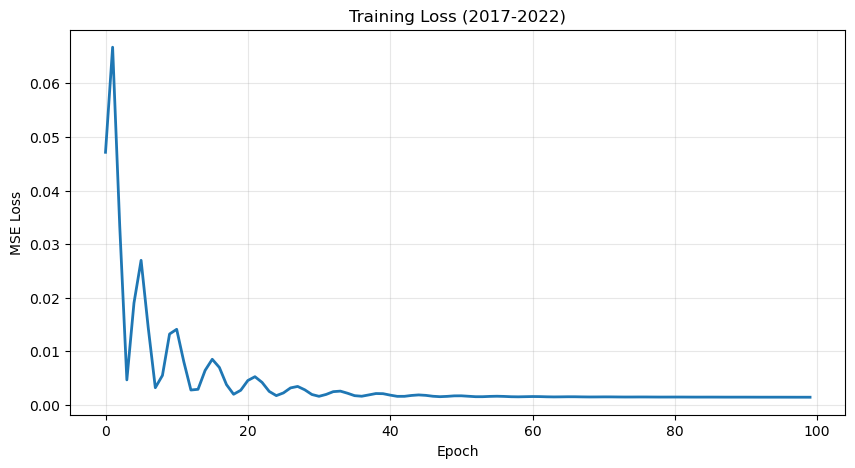


EVALUATION: Validation (2017-2022)
Original size: 46,070, After filtering unknown countries: 42,732
Validation (2017-2022) (all flows)                         | n=     5,308 | R²=0.0102 | SMAPE=178.31%
Validation (2017-2022) (>= 1,000,000 USD, 25.4%)           | n=     1,347 | R²=-0.0134 | SMAPE=130.09%
Validation (2017-2022) (>= 10,000,000 USD, 10.3%)          | n=       548 | R²=-0.0660 | SMAPE=117.04%
Validation (2017-2022) (>= 100,000,000 USD, 2.8%)          | n=       149 | R²=-0.2819 | SMAPE=165.46%

EVALUATION: Test 2023
Original size: 34,721, After filtering unknown countries: 32,064
Test 2023            (all flows)                         | n=       948 | R²=0.0550 | SMAPE=184.55%
Test 2023            (>= 1,000,000 USD, 23.6%)           | n=       224 | R²=0.1778 | SMAPE=144.86%
Test 2023            (>= 10,000,000 USD, 9.2%)           | n=        87 | R²=0.0440 | SMAPE=106.83%
Test 2023            (>= 100,000,000 USD, 2.3%)          | n=        22 | R²=-1.2900 | SMAPE=103.51%

In [17]:


# ==============================================================
# FUNCTIONS
# ==============================================================
def calculate_smape(y_true, y_pred):
    """Calcule SMAPE (0-200%, plus bas = meilleur)"""
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(numerator[mask] / denominator[mask]) * 100

def evaluate_metrics(y_true, y_pred, threshold=None, dataset_name="Dataset"):
    """Évaluer les métriques avec seuil optionnel"""
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    if threshold is not None:
        mask = y_true_flat >= threshold
        if mask.sum() < 10:
            print(f"⚠️ Pas assez de données >= {threshold:,}")
            return None
        y_true_flat = y_true_flat[mask]
        y_pred_flat = y_pred_flat[mask]
        n_total = len(y_true.flatten())
        pct = len(y_true_flat) / n_total * 100
        scope = f"(>= {threshold:,} USD, {pct:.1f}%)"
    else:
        scope = "(all flows)"

    mse = mean_squared_error(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    r2 = r2_score(y_true_flat, y_pred_flat)
    smape = calculate_smape(y_true_flat, y_pred_flat)

    print(f"{dataset_name:20s} {scope:35s} | n={len(y_true_flat):>10,} | R²={r2:.4f} | SMAPE={smape:.2f}%")

    return {'mse': mse, 'mae': mae, 'r2': r2, 'smape': smape, 'n': len(y_true_flat)}

def evaluate_dataset(model, df_eval, train_agg_features, country_code_map, scaler_features, scaler_target, batch_size, dataset_name):
    """Évaluer le modèle sur un dataset spécifique"""

    print(f"\n{'='*120}")
    print(f"EVALUATION: {dataset_name}")
    print(f"{'='*120}")

    df_eval = df_eval.copy()

    for col in ['gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist']:
        df_eval[col].fillna(df_eval[col].mean() if df_eval[col].mean() == df_eval[col].mean() else 0, inplace=True)

    df_eval['nodeID'] = df_eval['reporterCode'].map(country_code_map)
    df_eval['partnerNodeID'] = df_eval['partnerCode'].map(country_code_map)

    df_eval_filtered = df_eval.dropna(subset=['nodeID', 'partnerNodeID']).copy()
    df_eval_filtered['nodeID'] = df_eval_filtered['nodeID'].astype(int)
    df_eval_filtered['partnerNodeID'] = df_eval_filtered['partnerNodeID'].astype(int)

    print(f"Original size: {len(df_eval):,}, After filtering unknown countries: {len(df_eval_filtered):,}")

    if len(df_eval_filtered) == 0:
        print(f"⚠️ Pas de données pour {dataset_name}")
        return None, None, None

    agg_features_eval = df_eval_filtered.groupby(['refYear', 'reporterCode', 'cmdCode']).agg({
        'primaryValue': 'mean',
        'dist': 'first',
        'gdpcap_d': 'sum',
        'gdpcap_o': 'sum',
        'pop_d': 'sum',
        'pop_o': 'sum'
    }).reset_index()

    if USE_GDELT:
    	agg_features_eval = add_gdelt(agg_features_eval)

    eval_country_map = {code: i for i, code in enumerate(agg_features_eval['reporterCode'])}

    features_eval = agg_features_eval[FEAT_COLS]
    normalized_features_eval = scaler_features.transform(features_eval)
    normalized_target_eval = scaler_target.transform(agg_features_eval[['primaryValue']])

    df_eval_filtered['evalNodeID'] = df_eval_filtered['reporterCode'].map(eval_country_map)
    df_eval_filtered['evalPartnerID'] = df_eval_filtered['partnerCode'].map(eval_country_map)
    df_eval_filtered = df_eval_filtered.dropna(subset=['evalNodeID', 'evalPartnerID'])
    df_eval_filtered['evalNodeID'] = df_eval_filtered['evalNodeID'].astype(int)
    df_eval_filtered['evalPartnerID'] = df_eval_filtered['evalPartnerID'].astype(int)

    eval_g = dgl.graph((df_eval_filtered['evalNodeID'].to_numpy(),
                        df_eval_filtered['evalPartnerID'].to_numpy()))

    eval_feat_tensor = torch.tensor(normalized_features_eval, dtype=torch.float32)
    eval_g.ndata['feat'] = eval_feat_tensor
    eval_g = dgl.add_self_loop(eval_g)

    model.eval()
    predictions = []
    num_nodes_eval = eval_g.num_nodes()

    for i in range(0, num_nodes_eval, batch_size):
        batch_nodes = list(range(i, min(i + batch_size, num_nodes_eval)))
        batch_graph = eval_g.subgraph(batch_nodes)

        with torch.no_grad():
            logits = model(batch_graph, batch_graph.ndata['feat'])
            predictions.append(logits.unsqueeze(1))

    predictions = torch.cat(predictions, dim=0)
    predictions_np = predictions.view(predictions.size(0), -1).numpy()

    y_pred = scaler_target.inverse_transform(predictions_np)
    y_true = scaler_target.inverse_transform(normalized_target_eval)

    results = {}
    results['all'] = evaluate_metrics(y_true, y_pred, threshold=None, dataset_name=dataset_name)
    results['gte_1M'] = evaluate_metrics(y_true, y_pred, threshold=1_000_000, dataset_name=dataset_name)
    results['gte_10M'] = evaluate_metrics(y_true, y_pred, threshold=10_000_000, dataset_name=dataset_name)
    results['gte_100M'] = evaluate_metrics(y_true, y_pred, threshold=100_000_000, dataset_name=dataset_name)

    return results, y_true, y_pred

# ==============================================================
# DATA LOADING
# ==============================================================
print("="*60)
print("LOADING DATA")
print("="*60)

##source
df = pd.read_parquet("chips.parquet")

# getting numeric values
for c in ['gdp_o','gdp_d','gdpcap_o','gdpcap_d','dist','pop_o','pop_d','primaryValue','refYear','cmdCode','reporterCode','partnerCode']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['gdpcap_o'] = df['gdpcap_o'] / 1_000_000
df['gdp_o']    = df['gdp_o'] / 1_000_000
df['gdp_d']    = df['gdp_d'] / 1_000_000
df['gdpcap_d'] = df['gdpcap_d'] / 1_000_000
df['dist']     = df['dist'] / 1_000

df = df[df['cmdCode'] != 'TOTAL']
df = df[df['cmdCode'].astype(str).str.isdigit()]
df['cmdCode'] = df['cmdCode'].astype(int)
#df = df[df['cmdCode'] > 99999]

data_all = df[['refYear', 'reporterCode', 'partnerCode', 'cmdCode', 'gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist', 'primaryValue']]
data_all = data_all.drop_duplicates(['refYear', 'reporterCode', 'partnerCode', 'cmdCode'], keep='first').reset_index(drop=True)

# ==============================================================
# SPLIT PAR ANNÉE: Train 2017-2022, Test 2023
# ==============================================================
data_train_full = data_all[data_all['refYear'].isin([2017, 2018, 2019, 2020, 2021, 2022])].copy()
data_2023 = data_all[data_all['refYear'] == 2023].copy()

print(f"Train data (2017-2022): {data_train_full.shape[0]:,}")
print(f"Test 2023: {data_2023.shape[0]:,}")
print(f"Years in train: {sorted(data_train_full['refYear'].unique())}")

# Handle missing values
for col in ['gdpcap_o', 'pop_o']:
    data_train_full[col] = data_train_full.groupby(['refYear', 'reporterCode'])[col].transform(lambda x: x.fillna(x.mean()))
for col in ['gdpcap_d', 'pop_d']:
    data_train_full[col] = data_train_full.groupby(['refYear', 'partnerCode'])[col].transform(lambda x: x.fillna(x.mean()))
data_train_full['dist'] = data_train_full.groupby(['refYear', 'reporterCode', 'partnerCode'])['dist'].transform(lambda x: x.fillna(x.mean()))

for col in ['gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist']:
    data_train_full[col].fillna(data_train_full[col].mean(), inplace=True)

# ==============================================================
# TRAIN/VAL SPLIT (80/20)
# ==============================================================
grouped_data = data_train_full.groupby('reporterCode')
train_data = pd.DataFrame()
val_data = pd.DataFrame()

for name, group in grouped_data:
    if len(group) < 5:                 # too few rows to split — put them all in train
        train_data = pd.concat([train_data, group])
        continue
    train_group, val_group = train_test_split(group, test_size=0.2, random_state=42)
    train_data = pd.concat([train_data, train_group])
    val_data = pd.concat([val_data, val_group])

print(f"\nTrain size: {train_data.shape[0]:,}")
print(f"Validation size: {val_data.shape[0]:,}")

# ==============================================================
# FEATURE ENGINEERING
# ==============================================================
agg_features = train_data.groupby(['refYear', 'reporterCode', 'cmdCode']).agg({
    'primaryValue': 'mean',
    'dist': 'first',
    'gdpcap_d': 'sum',
    'gdpcap_o': 'sum',
    'pop_d': 'sum',
    'pop_o': 'sum'
}).reset_index()

if USE_GDELT:
    agg_features = add_gdelt(agg_features)

country_code_map = {code: i for i, code in enumerate(agg_features['reporterCode'])}

train_data = train_data.copy()
train_data.loc[:, 'nodeID'] = train_data['reporterCode'].map(country_code_map)

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

features_to_normalize = agg_features[FEAT_COLS]
normalized_features = scaler_features.fit_transform(features_to_normalize)
normalized_target = scaler_target.fit_transform(agg_features[['primaryValue']])

# ==============================================================
# CREATE GRAPH
# ==============================================================
g = dgl.graph((train_data['nodeID'].to_numpy(), train_data['partnerCode'].map(country_code_map).to_numpy()))
feat_tensor = torch.tensor(normalized_features, dtype=torch.float32)
g.ndata['feat'] = feat_tensor
g = dgl.add_self_loop(g)

print(f"\nGraph: {g.num_nodes()} nodes, {g.num_edges()} edges")

# ==============================================================
# MODEL
# ==============================================================
class GATRegressionModel(nn.Module):
    def __init__(self, in_feats, hidden_feats, num_heads):
        super(GATRegressionModel, self).__init__()
        self.conv1 = GATConv(in_feats, hidden_feats, num_heads)
        self.conv2 = GATConv(hidden_feats * num_heads, 1, num_heads)

    def forward(self, g, features):
        x = torch.relu(self.conv1(g, features).flatten(1))
        x = self.conv2(g, x).mean(1)
        return x

in_feats = len(FEAT_COLS)
hidden_feats = 32
num_heads = 4

model = GATRegressionModel(in_feats, hidden_feats, num_heads)

# ==============================================================
# TRAINING
# ==============================================================
batch_size = 10000
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
num_nodes = g.num_nodes()
num_batches = num_nodes // batch_size + (num_nodes % batch_size > 0)
num_epochs = 100

print("\n" + "="*60)
print("TRAINING (2017-2022)")
print("="*60)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for i in range(num_batches):
        batch_nodes = list(range(i * batch_size, min((i + 1) * batch_size, num_nodes)))
        batch_graph = g.subgraph(batch_nodes)

        logits = model(batch_graph, batch_graph.ndata['feat'])
        target = torch.tensor(normalized_target[batch_nodes, 0], dtype=torch.float32).view(-1, 1)

        loss = criterion(logits.view(-1, 1), target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{num_epochs} | Loss: {epoch_loss:.6f}')

print("\n✓ Training complete!")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (2017-2022)')
plt.grid(True, alpha=0.3)
plt.savefig('training_loss_2017_2022.png', dpi=300)
plt.show()

# ==============================================================
# EVALUATION: VALIDATION (2017-2022, 20%)
# ==============================================================
results_val, y_true_val, y_pred_val = evaluate_dataset(
    model, val_data, agg_features, country_code_map,
    scaler_features, scaler_target, batch_size, "Validation (2017-2022)"
)

# ==============================================================
# EVALUATION: TEST 2023
# ==============================================================
results_2023, y_true_2023, y_pred_2023 = evaluate_dataset(
    model, data_2023, agg_features, country_code_map,
    scaler_features, scaler_target, batch_size, "Test 2023"
)

if results_2023:
    for key, tr in [("all","all"),("gte_1M","1M"),("gte_10M","10M"),("gte_100M","100M")]:
        r = results_2023.get(key)
        if r:
            log_result(RUN["model"], RUN["fusion"], RUN["scoring"], RUN["gdelt"],
                       RUN["risk_level"], tr, r["r2"], r["mae"], r["smape"], r["n"])
    print("logged ->", RUN)

# ==============================================================
# DIAGNOSTIC PAR TRANCHE
# ==============================================================
print("\n" + "="*120)
print("DIAGNOSTIC PAR TRANCHE DE VALEURS (Validation 2017-2022)")
print("="*120)

if y_true_val is not None:
    y_true_flat = y_true_val.flatten()
    y_pred_flat = y_pred_val.flatten()

    tranches = [
        ('< 100K USD', y_true_flat < 100_000),
        ('100K - 1M USD', (y_true_flat >= 100_000) & (y_true_flat < 1_000_000)),
        ('1M - 10M USD', (y_true_flat >= 1_000_000) & (y_true_flat < 10_000_000)),
        ('10M - 100M USD', (y_true_flat >= 10_000_000) & (y_true_flat < 100_000_000)),
        ('> 100M USD', y_true_flat >= 100_000_000)
    ]

    for nom, mask in tranches:
        if mask.sum() > 1:
            r2_t = r2_score(y_true_flat[mask], y_pred_flat[mask])
            smape_t = calculate_smape(y_true_flat[mask], y_pred_flat[mask])
            print(f"{nom:25s} | n={mask.sum():>10,} | R²={r2_t:>8.4f} | SMAPE={smape_t:>6.2f}%")

# ==============================================================
# SUMMARY TABLE
# ==============================================================
print("\n" + "="*100)
print("SUMMARY TABLE")
print("="*100)

all_results = [
    ("Validation (2017-2022)", results_val),
    ("Test 2023", results_2023)
]

# Table >= 100M USD
print("\n--- Flux >= 100M USD ---")
print(f"{'Dataset':<25} | {'n':>8} | {'MSE':>15} | {'MAE':>12} | {'R²':>8} | {'SMAPE':>10}")
print("-"*90)

for name, results in all_results:
    if results and results.get('gte_100M'):
        r = results['gte_100M']
        print(f"{name:<25} | {r['n']:>8,} | {r['mse']:>15,.2f} | {r['mae']:>12,.2f} | {r['r2']:>8.4f} | {r['smape']:>9.2f}%")

# ==============================================================
# LATEX TABLE
# ==============================================================
print("\n" + "="*100)
print("LATEX TABLE (>= 100M USD)")
print("="*100)

print(r"""
\begin{table}[h]
\centering
\caption{GAT Model Performance for Trade Flow Prediction (trained on 2017-2022, flows $\geq$ 100M USD)}
\label{tab:results_2017_2022}
\begin{tabular}{l|r|r|r|c|c}
Dataset & n & MSE & MAE & R² & SMAPE \\
\hline""")

for name, results in all_results:
    if results and results.get('gte_100M'):
        r = results['gte_100M']
        print(f"{name} & {r['n']:,} & {r['mse']:,.2f} & {r['mae']:,.2f} & {r['r2']:.2f} & {r['smape']:.2f}\\% \\\\")

print(r"""\end{tabular}
\end{table}
""")

# ==============================================================
# SAVE MODEL
# ==============================================================
torch.save(model.state_dict(), 'model_gat_2017_2022_chips_gdelt.pth')
print("\n✓ Model saved")

In [3]:

# ===== EXPERIMENT CONFIG — change these to run each condition =====
USE_GDELT = True                       # False = baseline (no GDELT)
SCORING   = "keepall"                  # "keepall" | "topk"
GDELT_FILE = {"keepall": "gdelt_features_by_country_year.parquet",
              "topk":    "gdelt_features_topk.parquet"}[SCORING]

GDELT_COLS = ["events_total","score_mean","score_max","score_vol",
              "goldstein_wmean","tone_mean","active_months"]
BASE_COLS  = ['refYear','cmdCode','dist','gdpcap_d','gdpcap_o','pop_o','pop_d']
FEAT_COLS  = BASE_COLS + (GDELT_COLS if USE_GDELT else [])

if USE_GDELT:
    cy = pd.read_parquet(GDELT_FILE)

def add_gdelt(agg):
    """Concat GDELT country-year features onto agg (string-key merge = dtype-safe)."""
    out = agg.copy()
    out["_r"] = out["reporterCode"].astype("Int64").astype(str)
    out["_y"] = out["refYear"].astype("Int64").astype(str)
    cyk = cy.copy()
    cyk["_r"] = cyk["reporterCode"].astype("Int64").astype(str)
    cyk["_y"] = cyk["year"].astype("Int64").astype(str)
    out = out.merge(cyk[["_r","_y"]+GDELT_COLS], on=["_r","_y"], how="left")
    out[GDELT_COLS] = out[GDELT_COLS].fillna(0)
    return out.drop(columns=["_r","_y"])

def log_result(model, fusion, scoring, gdelt, risk_level, tranche, r2, mae, smape, n, notes=""):
    import os, csv
    from datetime import datetime
    RESULTS_FILE = "results.csv"
    row = {"timestamp": datetime.now().isoformat(timespec="seconds"),
           "model": model, "fusion": fusion, "scoring": scoring, "gdelt": gdelt,
           "risk_level": risk_level, "tranche": tranche,
           "r2": round(float(r2),4), "mae": round(float(mae),2),
           "smape": round(float(smape),2), "n": int(n), "notes": notes}
    new = not os.path.exists(RESULTS_FILE)
    with open(RESULTS_FILE, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if new: w.writeheader()
        w.writerow(row)
    return row

RUN = dict(model="GCN",
           fusion=("concat" if USE_GDELT else "none"),
           scoring=(SCORING if USE_GDELT else "none"),
           gdelt=USE_GDELT, risk_level="node")

LOADING DATA
Train data (2017-2022): 230,095
Test 2023: 34,721
Years in train: [2017, 2018, 2019, 2020, 2021, 2022]

Train size: 184,025
Validation size: 46,070

Graph: 6811 nodes, 190836 edges

TRAINING (2017-2022)
Epoch  10/100 | Loss: 0.003427
Epoch  20/100 | Loss: 0.001953
Epoch  30/100 | Loss: 0.001973
Epoch  40/100 | Loss: 0.001537
Epoch  50/100 | Loss: 0.001541
Epoch  60/100 | Loss: 0.001461
Epoch  70/100 | Loss: 0.001423
Epoch  80/100 | Loss: 0.001399
Epoch  90/100 | Loss: 0.001377
Epoch 100/100 | Loss: 0.001359

✓ Training complete!


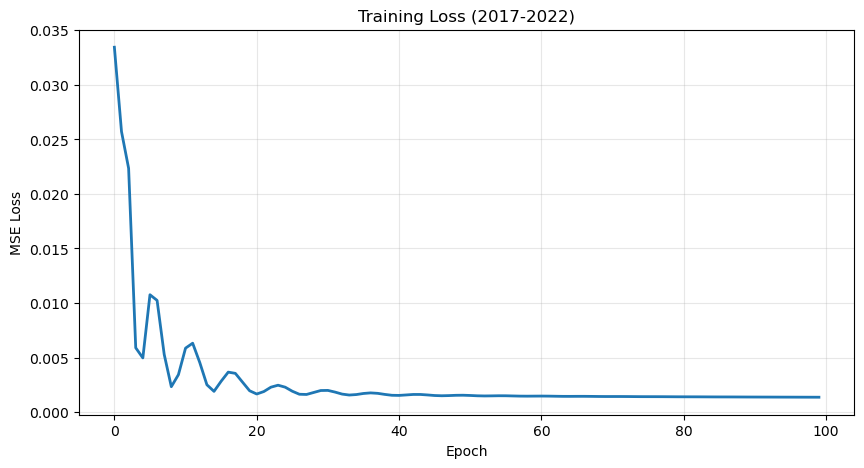


EVALUATION: Validation (2017-2022)
Original size: 46,070, After filtering unknown countries: 42,732
Validation (2017-2022) (all flows)                         | n=     5,308 | R²=-0.0011 | SMAPE=186.20%
Validation (2017-2022) (>= 1,000,000 USD, 25.4%)           | n=     1,347 | R²=-0.0269 | SMAPE=161.13%
Validation (2017-2022) (>= 10,000,000 USD, 10.3%)          | n=       548 | R²=-0.0805 | SMAPE=162.72%
Validation (2017-2022) (>= 100,000,000 USD, 2.8%)          | n=       149 | R²=-0.2978 | SMAPE=187.15%

EVALUATION: Test 2023
Original size: 34,721, After filtering unknown countries: 32,064
Test 2023            (all flows)                         | n=       948 | R²=0.0950 | SMAPE=180.07%
Test 2023            (>= 1,000,000 USD, 23.6%)           | n=       224 | R²=0.2166 | SMAPE=130.26%
Test 2023            (>= 10,000,000 USD, 9.2%)           | n=        87 | R²=0.1896 | SMAPE=85.60%
Test 2023            (>= 100,000,000 USD, 2.3%)          | n=        22 | R²=-0.8801 | SMAPE=96.19%


In [4]:


# ==============================================================
# FUNCTIONS
# ==============================================================
def calculate_smape(y_true, y_pred):
    """Calcule SMAPE (0-200%, plus bas = meilleur)"""
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(numerator[mask] / denominator[mask]) * 100

def evaluate_metrics(y_true, y_pred, threshold=None, dataset_name="Dataset"):
    """Évaluer les métriques avec seuil optionnel"""
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    if threshold is not None:
        mask = y_true_flat >= threshold
        if mask.sum() < 10:
            print(f"⚠️ Pas assez de données >= {threshold:,}")
            return None
        y_true_flat = y_true_flat[mask]
        y_pred_flat = y_pred_flat[mask]
        n_total = len(y_true.flatten())
        pct = len(y_true_flat) / n_total * 100
        scope = f"(>= {threshold:,} USD, {pct:.1f}%)"
    else:
        scope = "(all flows)"

    mse = mean_squared_error(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    r2 = r2_score(y_true_flat, y_pred_flat)
    smape = calculate_smape(y_true_flat, y_pred_flat)

    print(f"{dataset_name:20s} {scope:35s} | n={len(y_true_flat):>10,} | R²={r2:.4f} | SMAPE={smape:.2f}%")

    return {'mse': mse, 'mae': mae, 'r2': r2, 'smape': smape, 'n': len(y_true_flat)}

def evaluate_dataset(model, df_eval, train_agg_features, country_code_map, scaler_features, scaler_target, batch_size, dataset_name):
    """Évaluer le modèle sur un dataset spécifique"""

    print(f"\n{'='*120}")
    print(f"EVALUATION: {dataset_name}")
    print(f"{'='*120}")

    df_eval = df_eval.copy()

    for col in ['gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist']:
        df_eval[col].fillna(df_eval[col].mean() if df_eval[col].mean() == df_eval[col].mean() else 0, inplace=True)

    df_eval['nodeID'] = df_eval['reporterCode'].map(country_code_map)
    df_eval['partnerNodeID'] = df_eval['partnerCode'].map(country_code_map)

    df_eval_filtered = df_eval.dropna(subset=['nodeID', 'partnerNodeID']).copy()
    df_eval_filtered['nodeID'] = df_eval_filtered['nodeID'].astype(int)
    df_eval_filtered['partnerNodeID'] = df_eval_filtered['partnerNodeID'].astype(int)

    print(f"Original size: {len(df_eval):,}, After filtering unknown countries: {len(df_eval_filtered):,}")

    if len(df_eval_filtered) == 0:
        print(f"⚠️ Pas de données pour {dataset_name}")
        return None, None, None

    agg_features_eval = df_eval_filtered.groupby(['refYear', 'reporterCode', 'cmdCode']).agg({
        'primaryValue': 'mean',
        'dist': 'first',
        'gdpcap_d': 'sum',
        'gdpcap_o': 'sum',
        'pop_d': 'sum',
        'pop_o': 'sum'
    }).reset_index()

    if USE_GDELT:
    	agg_features_eval = add_gdelt(agg_features_eval)

    eval_country_map = {code: i for i, code in enumerate(agg_features_eval['reporterCode'])}

    features_eval = agg_features_eval[FEAT_COLS]
    normalized_features_eval = scaler_features.transform(features_eval)
    normalized_target_eval = scaler_target.transform(agg_features_eval[['primaryValue']])

    df_eval_filtered['evalNodeID'] = df_eval_filtered['reporterCode'].map(eval_country_map)
    df_eval_filtered['evalPartnerID'] = df_eval_filtered['partnerCode'].map(eval_country_map)
    df_eval_filtered = df_eval_filtered.dropna(subset=['evalNodeID', 'evalPartnerID'])
    df_eval_filtered['evalNodeID'] = df_eval_filtered['evalNodeID'].astype(int)
    df_eval_filtered['evalPartnerID'] = df_eval_filtered['evalPartnerID'].astype(int)

    eval_g = dgl.graph((df_eval_filtered['evalNodeID'].to_numpy(),
                        df_eval_filtered['evalPartnerID'].to_numpy()))

    eval_feat_tensor = torch.tensor(normalized_features_eval, dtype=torch.float32)
    eval_g.ndata['feat'] = eval_feat_tensor
    eval_g = dgl.add_self_loop(eval_g)

    model.eval()
    predictions = []
    num_nodes_eval = eval_g.num_nodes()

    for i in range(0, num_nodes_eval, batch_size):
        batch_nodes = list(range(i, min(i + batch_size, num_nodes_eval)))
        batch_graph = eval_g.subgraph(batch_nodes)

        with torch.no_grad():
            logits = model(batch_graph, batch_graph.ndata['feat'])
            predictions.append(logits.unsqueeze(1))

    predictions = torch.cat(predictions, dim=0)
    predictions_np = predictions.view(predictions.size(0), -1).numpy()

    y_pred = scaler_target.inverse_transform(predictions_np)
    y_true = scaler_target.inverse_transform(normalized_target_eval)

    results = {}
    results['all'] = evaluate_metrics(y_true, y_pred, threshold=None, dataset_name=dataset_name)
    results['gte_1M'] = evaluate_metrics(y_true, y_pred, threshold=1_000_000, dataset_name=dataset_name)
    results['gte_10M'] = evaluate_metrics(y_true, y_pred, threshold=10_000_000, dataset_name=dataset_name)
    results['gte_100M'] = evaluate_metrics(y_true, y_pred, threshold=100_000_000, dataset_name=dataset_name)

    return results, y_true, y_pred

# ==============================================================
# DATA LOADING
# ==============================================================
print("="*60)
print("LOADING DATA")
print("="*60)

##source
df = pd.read_parquet("chips.parquet")

# getting numeric values
for c in ['gdp_o','gdp_d','gdpcap_o','gdpcap_d','dist','pop_o','pop_d','primaryValue','refYear','cmdCode','reporterCode','partnerCode']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['gdpcap_o'] = df['gdpcap_o'] / 1_000_000
df['gdp_o']    = df['gdp_o'] / 1_000_000
df['gdp_d']    = df['gdp_d'] / 1_000_000
df['gdpcap_d'] = df['gdpcap_d'] / 1_000_000
df['dist']     = df['dist'] / 1_000

df = df[df['cmdCode'] != 'TOTAL']
df = df[df['cmdCode'].astype(str).str.isdigit()]
df['cmdCode'] = df['cmdCode'].astype(int)
#df = df[df['cmdCode'] > 99999]

data_all = df[['refYear', 'reporterCode', 'partnerCode', 'cmdCode', 'gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist', 'primaryValue']]
data_all = data_all.drop_duplicates(['refYear', 'reporterCode', 'partnerCode', 'cmdCode'], keep='first').reset_index(drop=True)

# ==============================================================
# SPLIT PAR ANNÉE: Train 2017-2022, Test 2023
# ==============================================================
data_train_full = data_all[data_all['refYear'].isin([2017, 2018, 2019, 2020, 2021, 2022])].copy()
data_2023 = data_all[data_all['refYear'] == 2023].copy()

print(f"Train data (2017-2022): {data_train_full.shape[0]:,}")
print(f"Test 2023: {data_2023.shape[0]:,}")
print(f"Years in train: {sorted(data_train_full['refYear'].unique())}")

# Handle missing values
for col in ['gdpcap_o', 'pop_o']:
    data_train_full[col] = data_train_full.groupby(['refYear', 'reporterCode'])[col].transform(lambda x: x.fillna(x.mean()))
for col in ['gdpcap_d', 'pop_d']:
    data_train_full[col] = data_train_full.groupby(['refYear', 'partnerCode'])[col].transform(lambda x: x.fillna(x.mean()))
data_train_full['dist'] = data_train_full.groupby(['refYear', 'reporterCode', 'partnerCode'])['dist'].transform(lambda x: x.fillna(x.mean()))

for col in ['gdpcap_o', 'pop_o', 'gdpcap_d', 'pop_d', 'dist']:
    data_train_full[col].fillna(data_train_full[col].mean(), inplace=True)

# ==============================================================
# TRAIN/VAL SPLIT (80/20)
# ==============================================================
grouped_data = data_train_full.groupby('reporterCode')
train_data = pd.DataFrame()
val_data = pd.DataFrame()

for name, group in grouped_data:
    if len(group) < 5:                 # too few rows to split — put them all in train
        train_data = pd.concat([train_data, group])
        continue
    train_group, val_group = train_test_split(group, test_size=0.2, random_state=42)
    train_data = pd.concat([train_data, train_group])
    val_data = pd.concat([val_data, val_group])

print(f"\nTrain size: {train_data.shape[0]:,}")
print(f"Validation size: {val_data.shape[0]:,}")

# ==============================================================
# FEATURE ENGINEERING
# ==============================================================
agg_features = train_data.groupby(['refYear', 'reporterCode', 'cmdCode']).agg({
    'primaryValue': 'mean',
    'dist': 'first',
    'gdpcap_d': 'sum',
    'gdpcap_o': 'sum',
    'pop_d': 'sum',
    'pop_o': 'sum'
}).reset_index()

if USE_GDELT:
    agg_features = add_gdelt(agg_features)

country_code_map = {code: i for i, code in enumerate(agg_features['reporterCode'])}

train_data = train_data.copy()
train_data.loc[:, 'nodeID'] = train_data['reporterCode'].map(country_code_map)

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

features_to_normalize = agg_features[FEAT_COLS]
normalized_features = scaler_features.fit_transform(features_to_normalize)
normalized_target = scaler_target.fit_transform(agg_features[['primaryValue']])

# ==============================================================
# CREATE GRAPH
# ==============================================================
g = dgl.graph((train_data['nodeID'].to_numpy(), train_data['partnerCode'].map(country_code_map).to_numpy()))
feat_tensor = torch.tensor(normalized_features, dtype=torch.float32)
g.ndata['feat'] = feat_tensor
g = dgl.add_self_loop(g)

print(f"\nGraph: {g.num_nodes()} nodes, {g.num_edges()} edges")

# ==============================================================
# MODEL
# ==============================================================
class GATRegressionModel(nn.Module):
    def __init__(self, in_feats, hidden_feats, num_heads):
        super(GATRegressionModel, self).__init__()
        self.conv1 = GATConv(in_feats, hidden_feats, num_heads)
        self.conv2 = GATConv(hidden_feats * num_heads, 1, num_heads)

    def forward(self, g, features):
        x = torch.relu(self.conv1(g, features).flatten(1))
        x = self.conv2(g, x).mean(1)
        return x

in_feats = len(FEAT_COLS)
hidden_feats = 32
num_heads = 4

model = GATRegressionModel(in_feats, hidden_feats, num_heads)

# ==============================================================
# TRAINING
# ==============================================================
batch_size = 10000
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
num_nodes = g.num_nodes()
num_batches = num_nodes // batch_size + (num_nodes % batch_size > 0)
num_epochs = 100

print("\n" + "="*60)
print("TRAINING (2017-2022)")
print("="*60)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for i in range(num_batches):
        batch_nodes = list(range(i * batch_size, min((i + 1) * batch_size, num_nodes)))
        batch_graph = g.subgraph(batch_nodes)

        logits = model(batch_graph, batch_graph.ndata['feat'])
        target = torch.tensor(normalized_target[batch_nodes, 0], dtype=torch.float32).view(-1, 1)

        loss = criterion(logits.view(-1, 1), target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{num_epochs} | Loss: {epoch_loss:.6f}')

print("\n✓ Training complete!")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (2017-2022)')
plt.grid(True, alpha=0.3)
plt.savefig('training_loss_2017_2022.png', dpi=300)
plt.show()

# ==============================================================
# EVALUATION: VALIDATION (2017-2022, 20%)
# ==============================================================
results_val, y_true_val, y_pred_val = evaluate_dataset(
    model, val_data, agg_features, country_code_map,
    scaler_features, scaler_target, batch_size, "Validation (2017-2022)"
)

# ==============================================================
# EVALUATION: TEST 2023
# ==============================================================
results_2023, y_true_2023, y_pred_2023 = evaluate_dataset(
    model, data_2023, agg_features, country_code_map,
    scaler_features, scaler_target, batch_size, "Test 2023"
)

if results_2023:
    for key, tr in [("all","all"),("gte_1M","1M"),("gte_10M","10M"),("gte_100M","100M")]:
        r = results_2023.get(key)
        if r:
            log_result(RUN["model"], RUN["fusion"], RUN["scoring"], RUN["gdelt"],
                       RUN["risk_level"], tr, r["r2"], r["mae"], r["smape"], r["n"])
    print("logged ->", RUN)

# ==============================================================
# DIAGNOSTIC PAR TRANCHE
# ==============================================================
print("\n" + "="*120)
print("DIAGNOSTIC PAR TRANCHE DE VALEURS (Validation 2017-2022)")
print("="*120)

if y_true_val is not None:
    y_true_flat = y_true_val.flatten()
    y_pred_flat = y_pred_val.flatten()

    tranches = [
        ('< 100K USD', y_true_flat < 100_000),
        ('100K - 1M USD', (y_true_flat >= 100_000) & (y_true_flat < 1_000_000)),
        ('1M - 10M USD', (y_true_flat >= 1_000_000) & (y_true_flat < 10_000_000)),
        ('10M - 100M USD', (y_true_flat >= 10_000_000) & (y_true_flat < 100_000_000)),
        ('> 100M USD', y_true_flat >= 100_000_000)
    ]

    for nom, mask in tranches:
        if mask.sum() > 1:
            r2_t = r2_score(y_true_flat[mask], y_pred_flat[mask])
            smape_t = calculate_smape(y_true_flat[mask], y_pred_flat[mask])
            print(f"{nom:25s} | n={mask.sum():>10,} | R²={r2_t:>8.4f} | SMAPE={smape_t:>6.2f}%")

# ==============================================================
# SUMMARY TABLE
# ==============================================================
print("\n" + "="*100)
print("SUMMARY TABLE")
print("="*100)

all_results = [
    ("Validation (2017-2022)", results_val),
    ("Test 2023", results_2023)
]

# Table >= 100M USD
print("\n--- Flux >= 100M USD ---")
print(f"{'Dataset':<25} | {'n':>8} | {'MSE':>15} | {'MAE':>12} | {'R²':>8} | {'SMAPE':>10}")
print("-"*90)

for name, results in all_results:
    if results and results.get('gte_100M'):
        r = results['gte_100M']
        print(f"{name:<25} | {r['n']:>8,} | {r['mse']:>15,.2f} | {r['mae']:>12,.2f} | {r['r2']:>8.4f} | {r['smape']:>9.2f}%")

# ==============================================================
# LATEX TABLE
# ==============================================================
print("\n" + "="*100)
print("LATEX TABLE (>= 100M USD)")
print("="*100)

print(r"""
\begin{table}[h]
\centering
\caption{GAT Model Performance for Trade Flow Prediction (trained on 2017-2022, flows $\geq$ 100M USD)}
\label{tab:results_2017_2022}
\begin{tabular}{l|r|r|r|c|c}
Dataset & n & MSE & MAE & R² & SMAPE \\
\hline""")

for name, results in all_results:
    if results and results.get('gte_100M'):
        r = results['gte_100M']
        print(f"{name} & {r['n']:,} & {r['mse']:,.2f} & {r['mae']:,.2f} & {r['r2']:.2f} & {r['smape']:.2f}\\% \\\\")

print(r"""\end{tabular}
\end{table}
""")

# ==============================================================
# SAVE MODEL
# ==============================================================
torch.save(model.state_dict(), 'model_gat_2017_2022_chips_gdelt.pth')
print("\n✓ Model saved")

In [18]:
import pandas as pd
r = pd.read_csv("results.csv")
print(r.shape)
print(r[["model","fusion","scoring","gdelt","tranche","r2"]].tail(8))

(8, 12)
  model  fusion  scoring  gdelt tranche      r2
0   GAT  concat  keepall   True     all  0.1171
1   GAT  concat  keepall   True      1M  0.2350
2   GAT  concat  keepall   True     10M  0.1768
3   GAT  concat  keepall   True    100M -0.9439
4   GAT  concat     topk   True     all  0.0550
5   GAT  concat     topk   True      1M  0.1778
6   GAT  concat     topk   True     10M  0.0440
7   GAT  concat     topk   True    100M -1.2900


In [19]:
r = pd.read_csv("results.csv")
r = r.drop_duplicates(subset=["model","fusion","scoring","gdelt","risk_level","tranche"], keep="last")

view = (r[r.tranche=="100M"]
        .assign(cond=lambda d: d.gdelt.map({False:"no-GDELT",True:"GDELT"})+" / "+d.scoring)
        .pivot_table(index="model", columns="cond", values="r2"))
print(view.round(3))

cond   GDELT / keepall  GDELT / topk
model                               
GAT             -0.944         -1.29


---

In [1]:
import dgl

In [2]:
print('dgl',dgl.__version__)

dgl 2.4.0
